In [11]:
import joblib
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

In [12]:
MODELS_DIR = "models"
SEED = 42


def gini(y_true, y_score):
    """Gini coefficient = 2 * AUC - 1"""
    return 2.0 * roc_auc_score(y_true, y_score) - 1.0

In [13]:
test_df = pd.read_parquet("data/df_test_preprocessed.parquet")

id_cols = ["month_decision", "weekday_decision", "WEEK_NUM", "case_id"]

test_df = test_df.sort_values("WEEK_NUM", kind="mergesort").reset_index(drop=True)
week_num_test = test_df["WEEK_NUM"].copy()

test_df = test_df.drop(columns=id_cols)

X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]

print(f"Test shape: {X_test.shape}")
print(f"Weeks: {week_num_test.min()} - {week_num_test.max()} "
      f"({week_num_test.nunique()} unieke weken)")
print(f"Default rate: {y_test.mean():.4f} ({int(y_test.sum())} positieven)")


Test shape: (437823, 201)
Weeks: 53 - 91 (39 unieke weken)
Default rate: 0.0328 (14376 positieven)


In [14]:
# --- Load models ---

# Logistic Regression
lr_best = joblib.load(f"{MODELS_DIR}/lr_best.joblib")

# XGBoost
xgb_best = XGBClassifier()
xgb_best.load_model(f"{MODELS_DIR}/xgb_best.json")

# MLP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_best = torch.jit.load(f"{MODELS_DIR}/mlp_best.pt", map_location=device).eval()

mlp_weights = [v for k, v in mlp_best.state_dict().items() if k.endswith("weight")]
mlp_n_features = mlp_weights[0].shape[1]
mlp_hidden = [w.shape[0] for w in mlp_weights[:-1]]

print("LR :", f"C={lr_best.C:.6g}, l1_ratio={lr_best.l1_ratio}, "
              f"n_features={lr_best.n_features_in_}")
print("XGB:", f"n_trees={xgb_best.get_booster().num_boosted_rounds()}, "
              f"n_features={xgb_best.n_features_in_}")
print("MLP:", f"hidden={mlp_hidden}, n_features={mlp_n_features}")
print("Device:", device)


LR : C=0.000350674, l1_ratio=0.0, n_features=201
XGB: n_trees=750, n_features=201
MLP: hidden=[128], n_features=201
Device: cpu


c:\Users\Vik\Documents\UGent\Masterproef\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## SHAP timing test (PermutationExplainer)

Eenmalige meting: hoe lang duurt `PermutationExplainer` op het MLP-model,
op logit-schaal, met een achtergrond van 100 vs. 50 rijen?

In [15]:
import time

import shap

N_INSTANCES = 1000

# 300 willekeurige rijen uit één week testdata
one_week = week_num_test.min()
week_mask = (week_num_test == one_week).to_numpy()
X_week = X_test.loc[week_mask]

rng = np.random.default_rng(SEED)
instance_idx = rng.choice(X_week.index, size=N_INSTANCES, replace=False)
X_instances = X_week.loc[instance_idx].to_numpy(dtype=np.float32)

# achtergrond: willekeurige rijen uit de trainingsdata
train_df_bg = pd.read_parquet("data/df_train_preprocessed.parquet")
train_df_bg = train_df_bg.drop(columns=id_cols + ["target"])

bg_idx_100 = rng.choice(train_df_bg.index, size=100, replace=False)
X_bg_100 = train_df_bg.loc[bg_idx_100].to_numpy(dtype=np.float32)
X_bg_50 = X_bg_100[:50]

print(f"Testweek gebruikt: {one_week}")
print(f"X_instances shape: {X_instances.shape}")
print(f"X_bg_100 shape: {X_bg_100.shape}, X_bg_50 shape: {X_bg_50.shape}")


# Wrapper die de ruwe logit teruggeeft i.p.v. predict_proba (kansschaal).
# mlp_best.forward() geeft al de logit terug (zie MLP-definitie in
# m3_modelling.ipynb: laatste laag is nn.Linear zonder sigmoid erna).
def mlp_logit(X):
    x = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        return mlp_best(x).numpy()


Testweek gebruikt: 53
X_instances shape: (1000, 201)
X_bg_100 shape: (100, 201), X_bg_50 shape: (50, 201)


In [16]:
# --- Run 1: achtergrond van 100 rijen ---
explainer_100 = shap.explainers.Permutation(mlp_logit, X_bg_100, seed=SEED)

start = time.time()
sv_100 = explainer_100(X_instances)
time_100 = time.time() - start

print(f"Achtergrond=100: {time_100:.1f} s totaal "
      f"({time_100 / N_INSTANCES:.3f} s per instantie)")


PermutationExplainer explainer: 1001it [00:28, 22.98it/s]                         

Achtergrond=100: 28.4 s totaal (0.028 s per instantie)


In [17]:
# --- Run 2: achtergrond van 50 rijen ---
explainer_50 = shap.explainers.Permutation(mlp_logit, X_bg_50, seed=SEED)

start = time.time()
sv_50 = explainer_50(X_instances)
time_50 = time.time() - start

print(f"Achtergrond=50: {time_50:.1f} s totaal "
      f"({time_50 / N_INSTANCES:.3f} s per instantie)")

PermutationExplainer explainer: 1001it [00:13, 17.15it/s]                         

Achtergrond=50: 13.1 s totaal (0.013 s per instantie)


In [18]:
# --- Overzicht en extrapolatie naar 92 weken (300 instanties/week) ---
N_WEEKS = 92

est_100 = time_100 * N_WEEKS
est_50 = time_50 * N_WEEKS

print(f"Tijd voor 300 instanties, achtergrond=100: {time_100:.1f} s "
      f"({time_100 / 60:.1f} min)")
print(f"Tijd voor 300 instanties, achtergrond=50:  {time_50:.1f} s "
      f"({time_50 / 60:.1f} min)")
print()
print(f"Geschat voor 92 weken, achtergrond=100: {est_100 / 60:.1f} min "
      f"({est_100 / 3600:.2f} u)")
print(f"Geschat voor 92 weken, achtergrond=50:  {est_50 / 60:.1f} min "
      f"({est_50 / 3600:.2f} u)")
print()
haalbaar = "haalbaar binnen een paar uur" if min(
    est_100, est_50) / 3600 <= 4 else "niet haalbaar binnen een paar uur, de opzet moet aangepast worden"
print(f"Conclusie: op basis van deze meting is de volledige 92-weken run {haalbaar}.")


Tijd voor 300 instanties, achtergrond=100: 28.4 s (0.5 min)
Tijd voor 300 instanties, achtergrond=50:  13.1 s (0.2 min)

Geschat voor 92 weken, achtergrond=100: 43.5 min (0.73 u)
Geschat voor 92 weken, achtergrond=50:  20.0 min (0.33 u)

Conclusie: op basis van deze meting is de volledige 92-weken run haalbaar binnen een paar uur.


### Visualisatie van de SHAP-waarden (achtergrond=100)

Beeswarm-plot: elke stip is één instantie, kleur = waarde van de feature
(rood = hoog, blauw = laag), positie op de x-as = impact op de logit.

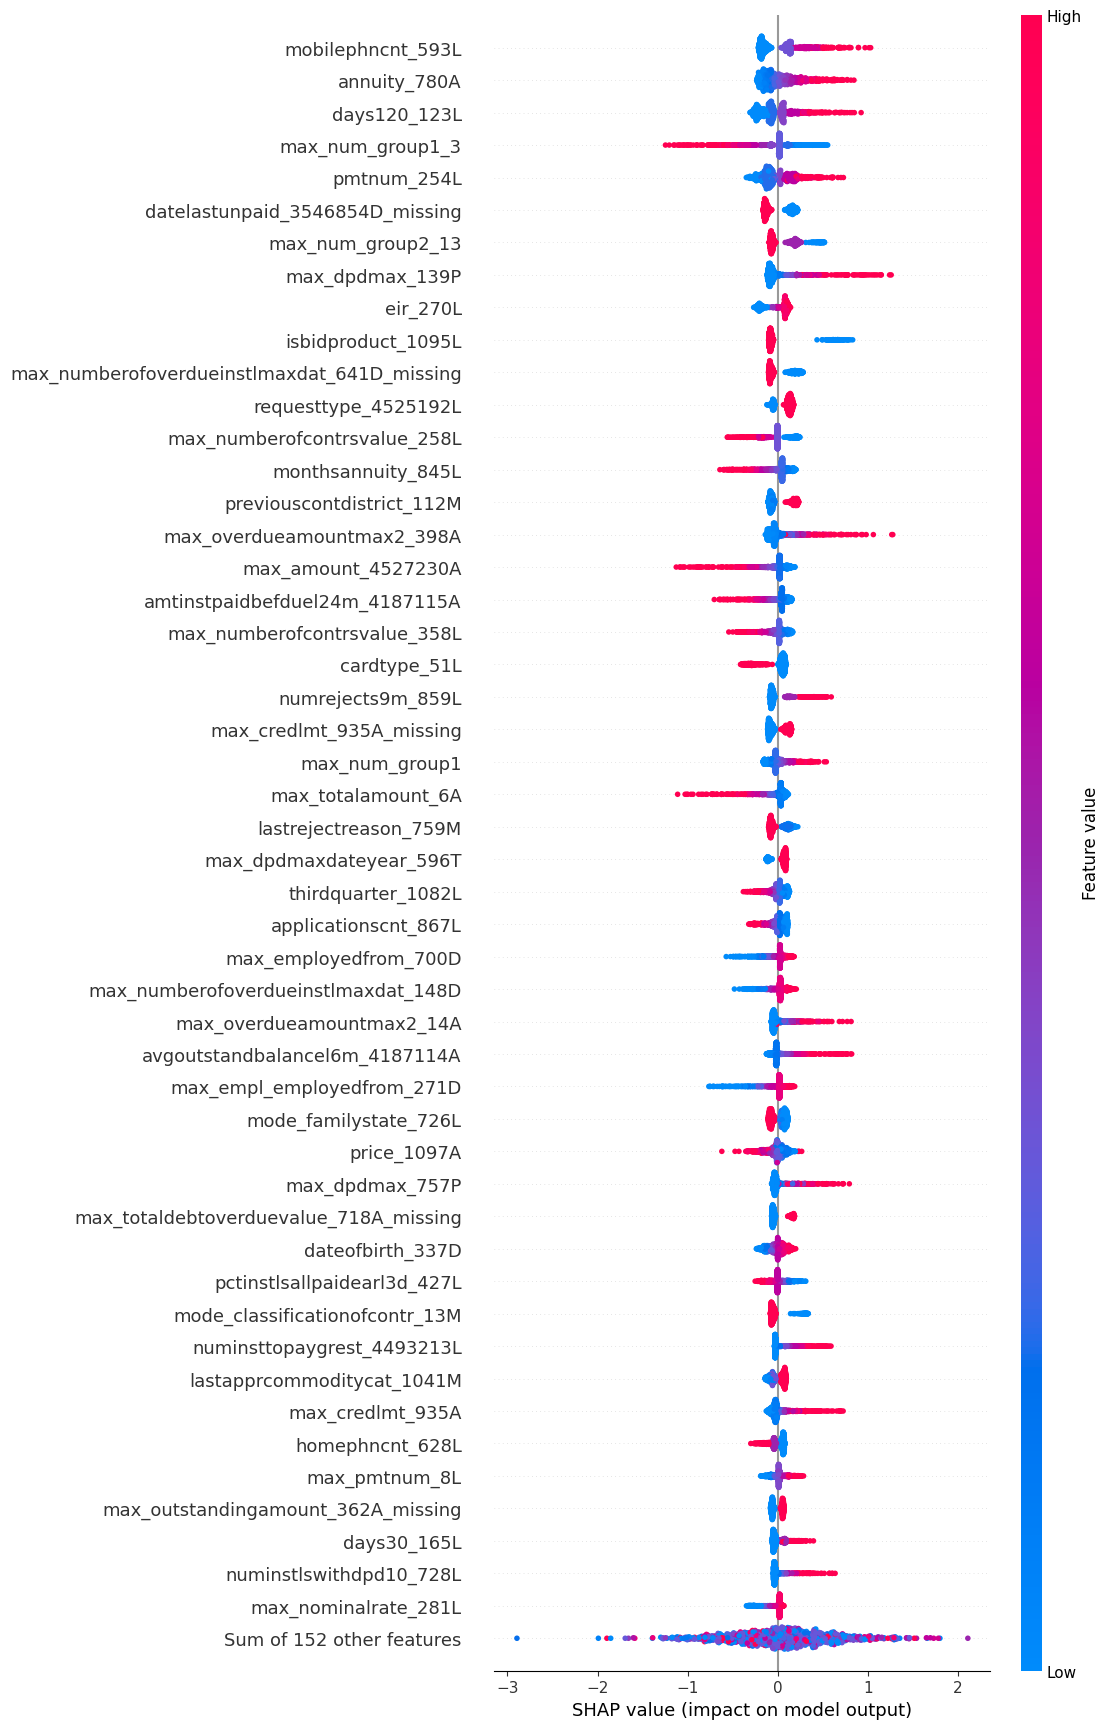

In [19]:
sv_100.feature_names = list(X_test.columns)
shap.plots.beeswarm(sv_100, max_display=50)